In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from scipy.cluster.hierarchy import dendrogram, linkage

In [2]:
df = pd.read_csv(r"C:\Users\inter\Desktop\Shrutika\Python-Practical\ML clustering project wholesale customer\Wholesale customers data.csv")
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [3]:
df.shape

(440, 8)

In [4]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Channel,440.0,1.322727,0.468052,1.0,1.00,1.0,2.00,2.0
Region,440.0,2.543182,0.774272,1.0,2.00,3.0,3.00,3.0
Fresh,440.0,12000.297727,12647.328865,3.0,3127.75,8504.0,16933.75,112151.0
Milk,440.0,5796.265909,7380.377175,55.0,1533.00,3627.0,7190.25,73498.0
Grocery,440.0,7951.277273,9503.162829,3.0,2153.00,4755.5,10655.75,92780.0
Frozen,440.0,3071.931818,4854.673333,25.0,742.25,1526.0,3554.25,60869.0
Detergents_Paper,440.0,2881.493182,4767.854448,3.0,256.75,816.5,3922.00,40827.0
Delicassen,440.0,1524.870455,2820.105937,3.0,408.25,965.5,1820.25,47943.0


In [5]:
#Data Cleaning
df.isnull().sum()

Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64

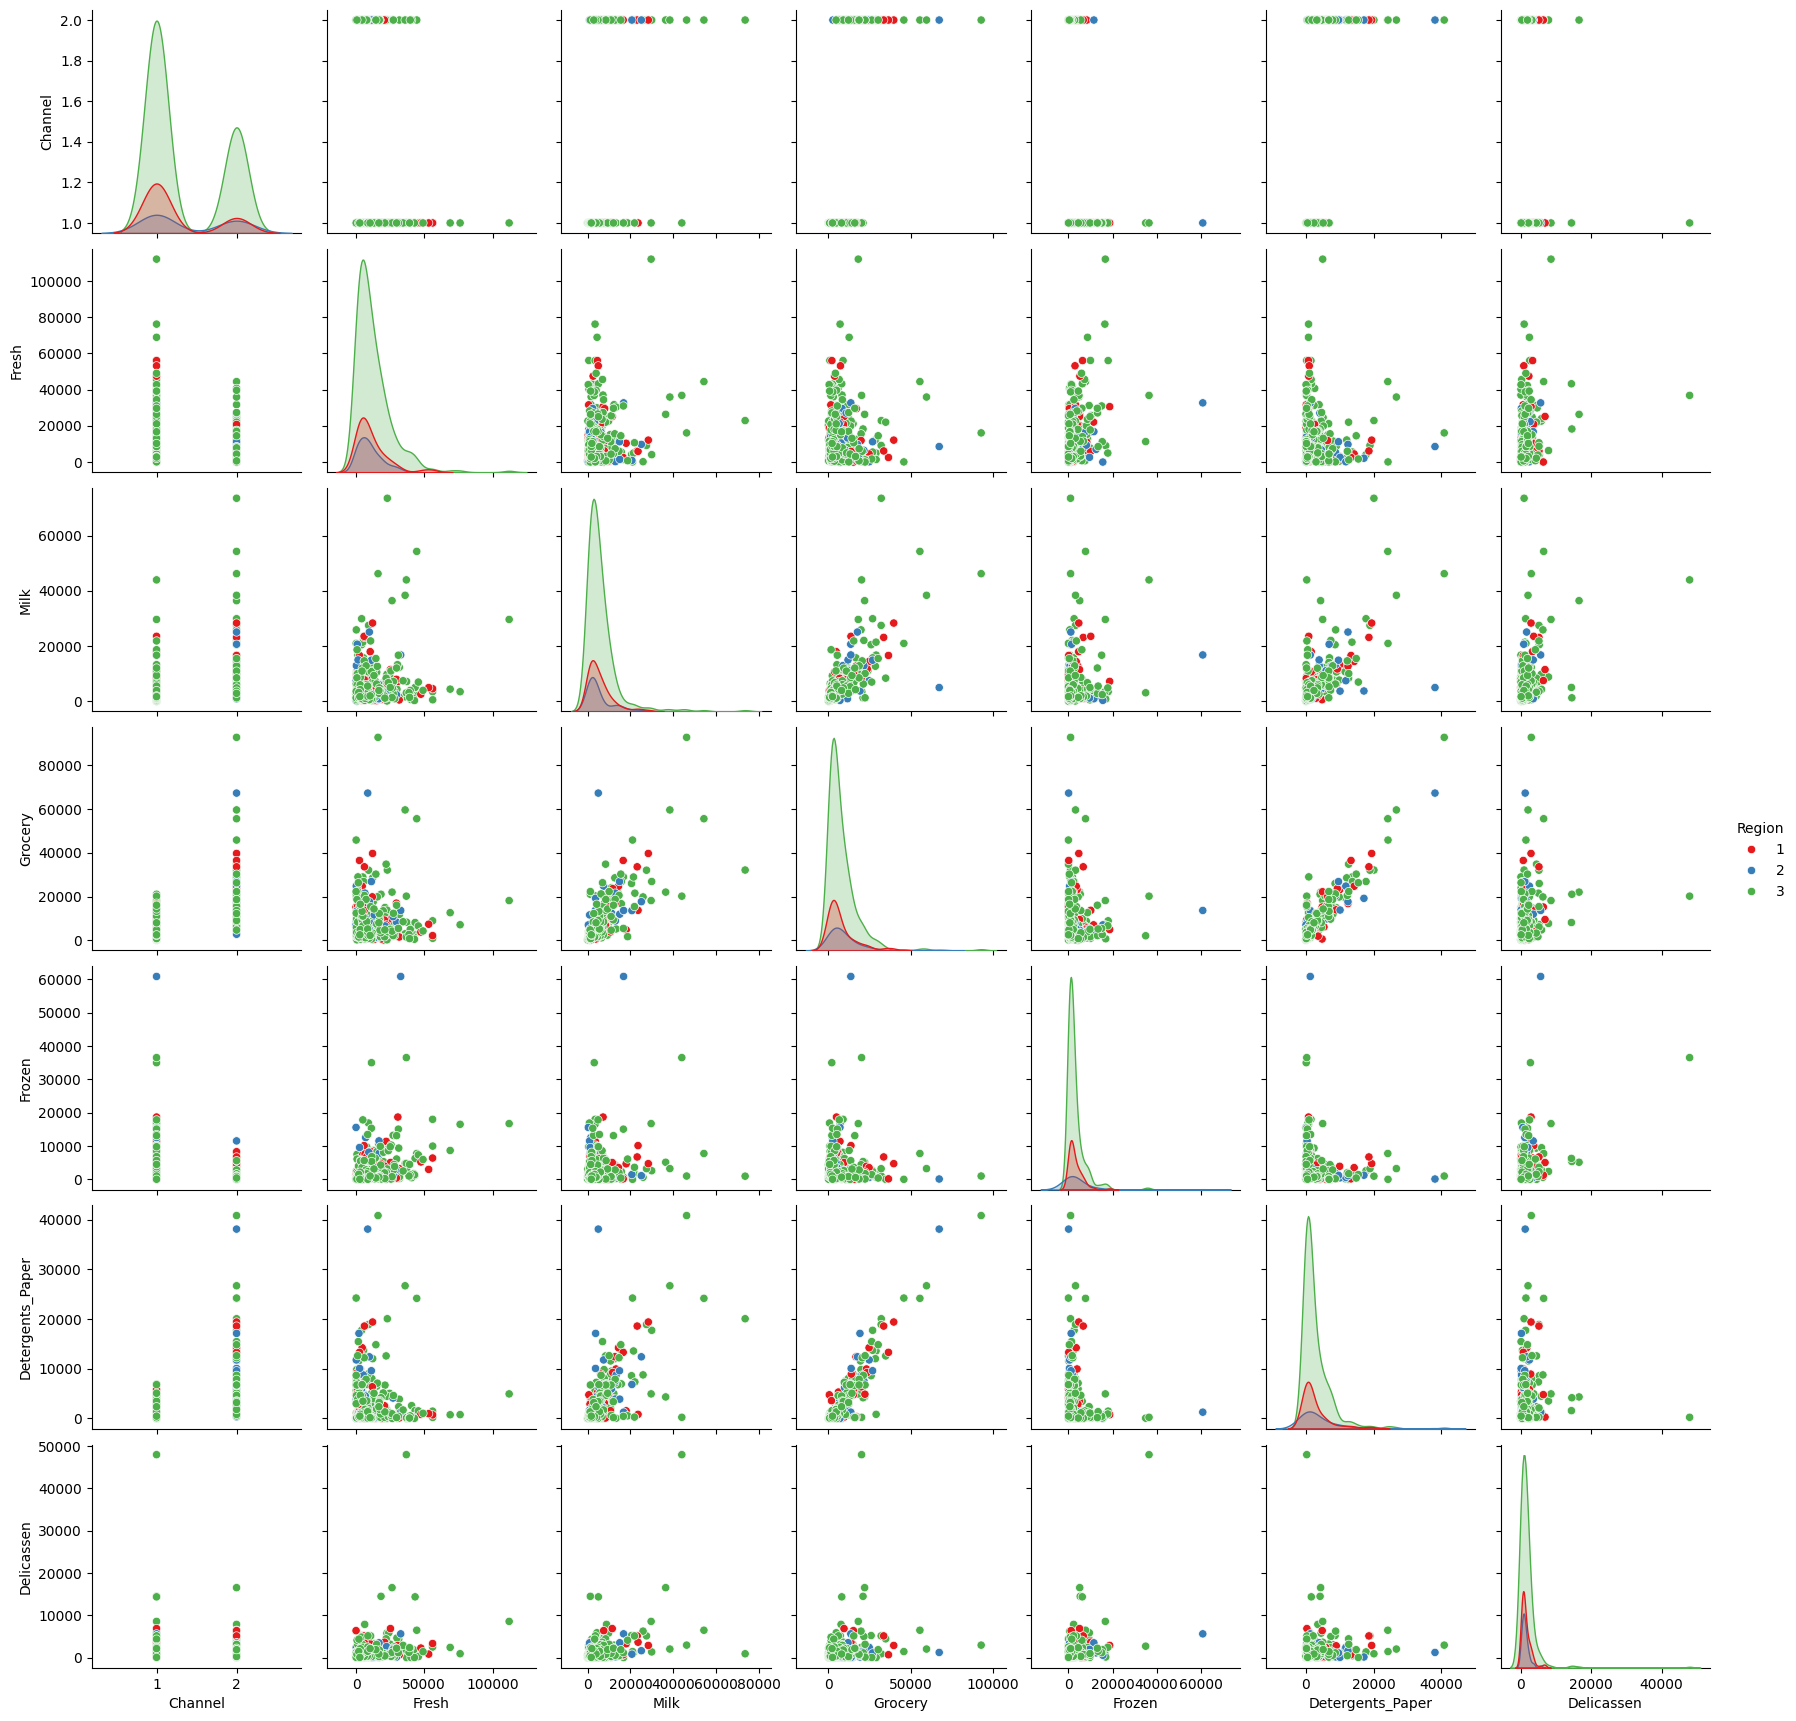

In [6]:
#Data Visualization
#1.pairplot
sns.pairplot(df, hue="Region", palette="Set1")
plt.show()

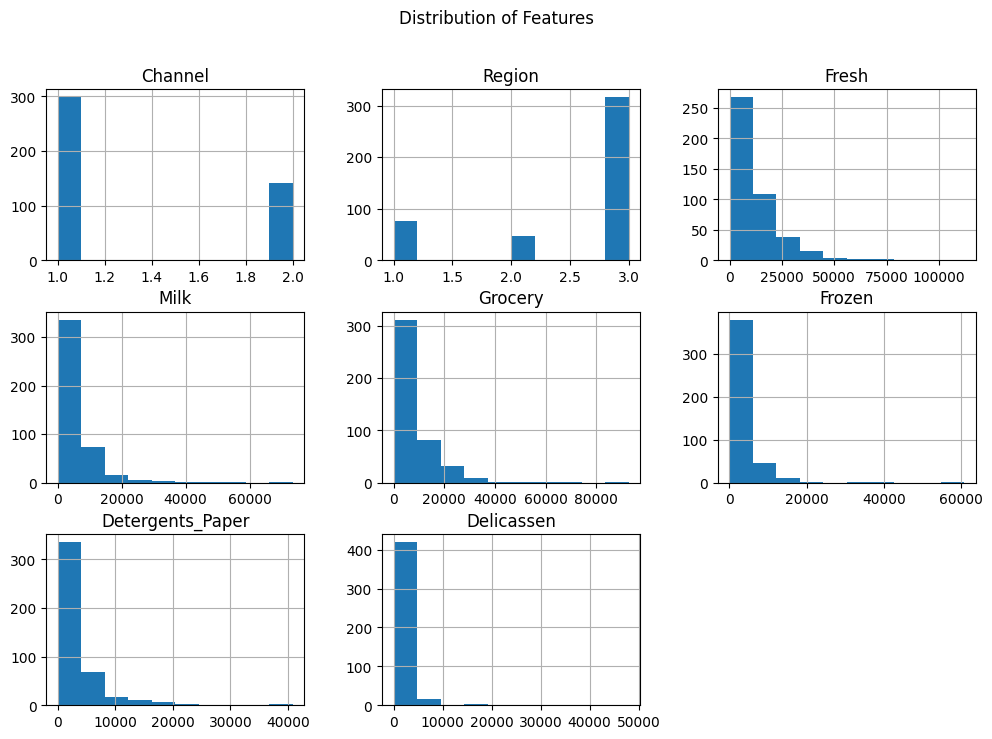

In [7]:
#2.Histplot
df.hist(figsize=(12, 8), bins=10)
plt.suptitle("Distribution of Features")
plt.show()

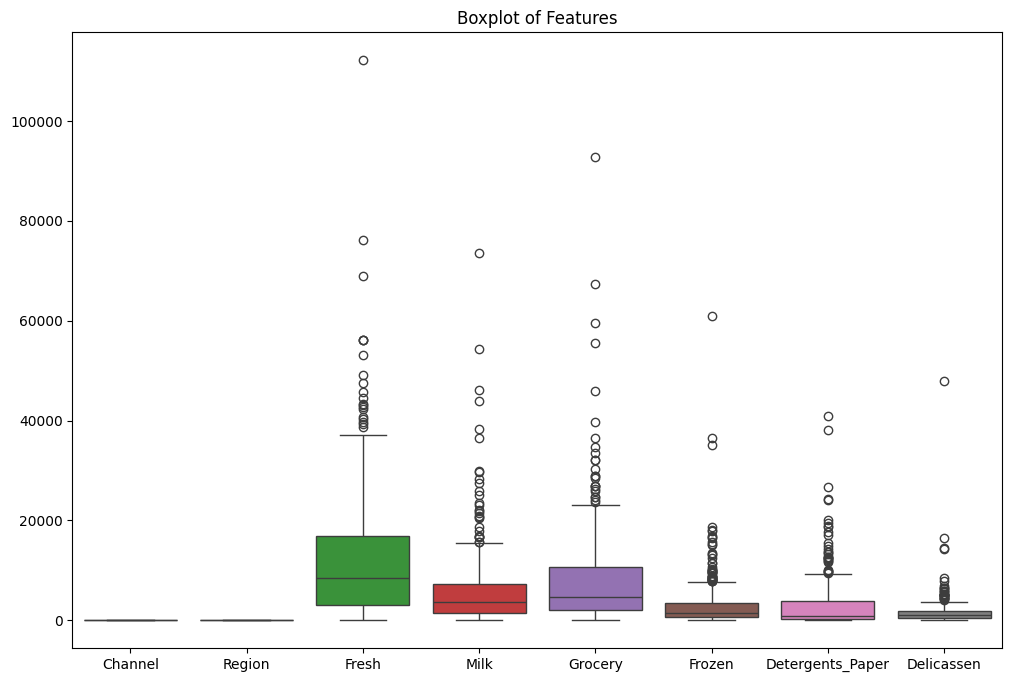

In [8]:
# 3.Boxplot
plt.figure(figsize=(12, 8))
plt.title("Boxplot of Features")
sns.boxplot(data=df)
plt.show()

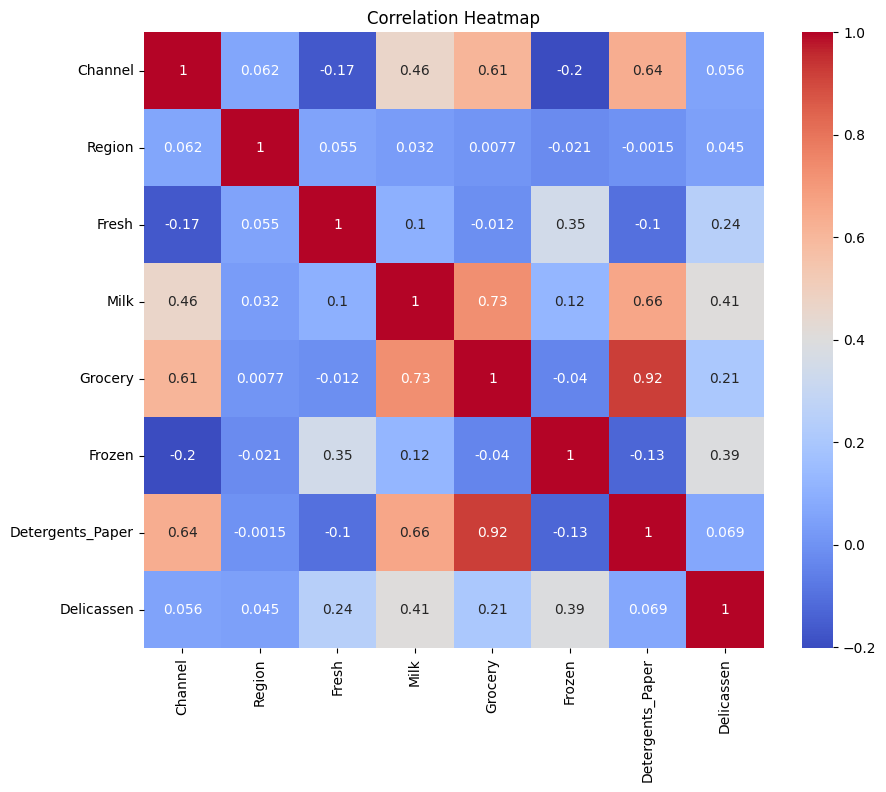

In [9]:
# 4.Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [10]:
features = df.drop(['Channel', 'Region'], axis=1)

In [11]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

print("Scaled Features:", scaled_features[:5])  # Display the first 5 rows of scaled features

Scaled Features: [[ 0.05293319  0.52356777 -0.04111489 -0.58936716 -0.04356873 -0.06633906]
 [-0.39130197  0.54445767  0.17031835 -0.27013618  0.08640684  0.08915105]
 [-0.44702926  0.40853771 -0.0281571  -0.13753572  0.13323164  2.24329255]
 [ 0.10011141 -0.62401993 -0.3929769   0.6871443  -0.49858822  0.09341105]
 [ 0.84023948 -0.05239645 -0.07935618  0.17385884 -0.23191782  1.29934689]]


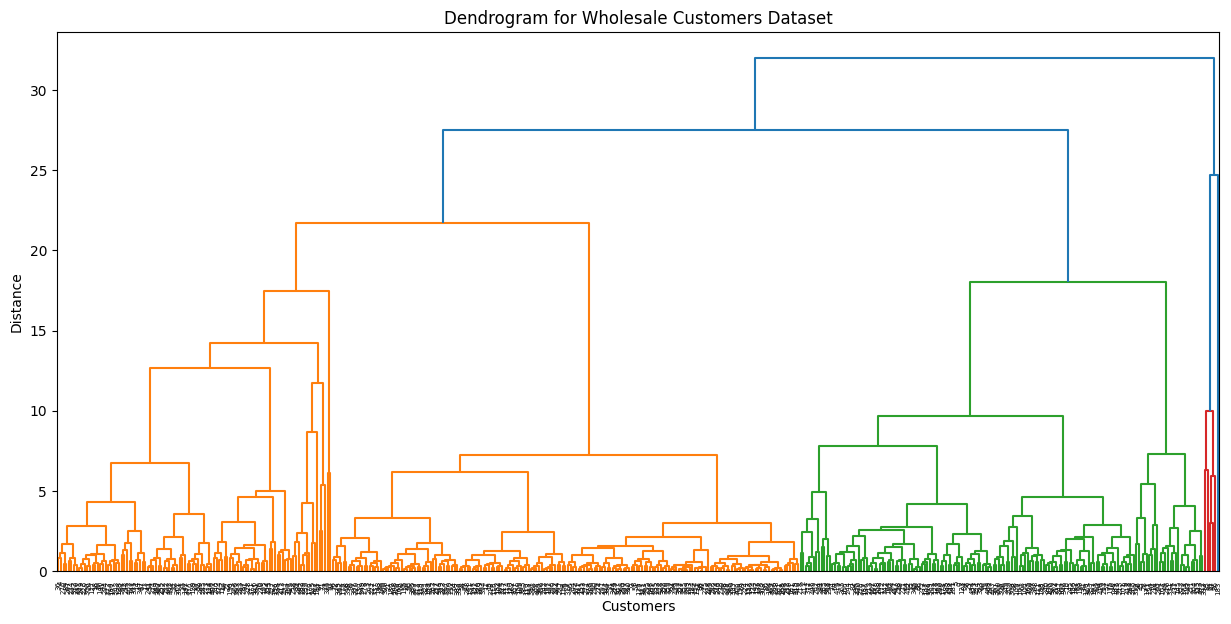

In [22]:
linked = linkage(scaled_features, method='ward')

plt.figure(figsize=(15,7))

dendrogram(
    linked,
    orientation='top',
    distance_sort='descending',
    show_leaf_counts=False
)

plt.title("Dendrogram for Wholesale Customers Dataset")
plt.xlabel("Customers")
plt.ylabel("Distance")
plt.show()

In [13]:
#Apply agglomerative clustering to the scaled features
agg_clustering=AgglomerativeClustering(n_clusters=3)
clusters=agg_clustering.fit_predict(scaled_features)

#add the cluster labels to the original dataframe
df['cluster']=clusters
print("Agglomerative Clustering applied and cluster labels added to the dataset.")
df.head()

Agglomerative Clustering applied and cluster labels added to the dataset.


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,cluster
0,2,3,12669,9656,7561,214,2674,1338,2
1,2,3,7057,9810,9568,1762,3293,1776,2
2,2,3,6353,8808,7684,2405,3516,7844,2
3,1,3,13265,1196,4221,6404,507,1788,1
4,2,3,22615,5410,7198,3915,1777,5185,1


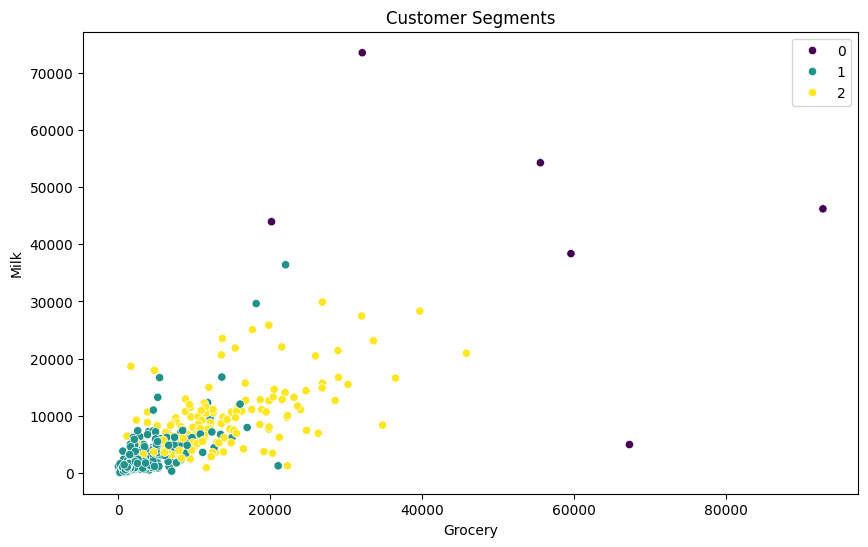

In [14]:
#Visualize the agglomartive clusters using a scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Grocery',y='Milk',hue='cluster',palette='viridis',data=df)
plt.title("Customer Segments")
plt.xlabel("Grocery")
plt.ylabel("Milk")
plt.legend()
plt.show()

In [15]:
#KMEans Clustering
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(scaled_features)
df['kmeans_cluster'] = kmeans.labels_
print(df.head())

   Channel  Region  Fresh  Milk  Grocery  Frozen  Detergents_Paper  \
0        2       3  12669  9656     7561     214              2674   
1        2       3   7057  9810     9568    1762              3293   
2        2       3   6353  8808     7684    2405              3516   
3        1       3  13265  1196     4221    6404               507   
4        2       3  22615  5410     7198    3915              1777   

   Delicassen  cluster  kmeans_cluster  
0        1338        2               0  
1        1776        2               0  
2        7844        2               0  
3        1788        1               0  
4        5185        1               1  


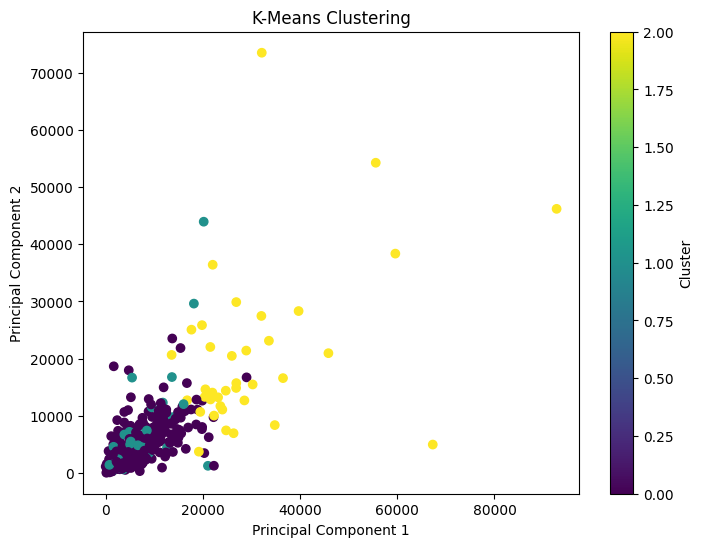

In [16]:
#Visualize kmeans clusters using a scatter plot
plt.figure(figsize=(8,6))
plt.scatter(df['Grocery'],df['Milk'],  
            c=df['kmeans_cluster'],
            cmap='viridis')

plt.title("K-Means Clustering")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label="Cluster")
plt.show()

In [34]:
dbscan = DBSCAN(
    eps=1.8,
    min_samples=5
)

dbscan_cluster = dbscan.fit_predict(scaled_features)

df['dbscan_cluster'] = dbscan.labels_
print(df.head())

   Channel  Region  Fresh  Milk  Grocery  Frozen  Detergents_Paper  \
0        2       3  12669  9656     7561     214              2674   
1        2       3   7057  9810     9568    1762              3293   
2        2       3   6353  8808     7684    2405              3516   
3        1       3  13265  1196     4221    6404               507   
4        2       3  22615  5410     7198    3915              1777   

   Delicassen  cluster  kmeans_cluster  dbscan_cluster  
0        1338        2               0               0  
1        1776        2               0               0  
2        7844        2               0               0  
3        1788        1               0               0  
4        5185        1               1               0  


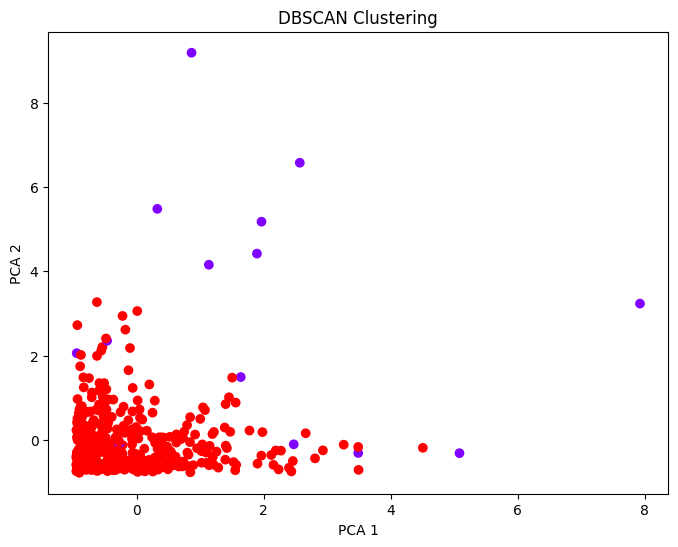

In [35]:
plt.figure(figsize=(8,6))

plt.scatter(
    scaled_features[:, 0],
    scaled_features[:, 1],
    c=dbscan_cluster,
    cmap='rainbow'
)

plt.title("DBSCAN Clustering")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

In [36]:
print("Agglomerative Cluster Counts")
print(df['cluster'].value_counts())

print("\nK-Means Cluster Counts")
print(df['kmeans_cluster'].value_counts())

print("\nDBSCAN Cluster Counts")
print(df['dbscan_cluster'].value_counts())

Agglomerative Cluster Counts
cluster
1    281
2    153
0      6
Name: count, dtype: int64

K-Means Cluster Counts
kmeans_cluster
0    350
1     53
2     37
Name: count, dtype: int64

DBSCAN Cluster Counts
dbscan_cluster
 0    424
-1     16
Name: count, dtype: int64


In [37]:
from sklearn.metrics import silhouette_score

# Agglomerative
agg_score = silhouette_score(scaled_features, df['cluster'])

# K-Means
kmeans_score = silhouette_score(scaled_features, df['kmeans_cluster'])

# DBSCAN
dbscan_score = silhouette_score(scaled_features, df['dbscan_cluster'])

print("Agglomerative Silhouette Score:", agg_score)
print("K-Means Silhouette Score:", kmeans_score)
print("DBSCAN Silhouette Score:", dbscan_score)

Agglomerative Silhouette Score: 0.2646091480214908
K-Means Silhouette Score: 0.4582633767207058
DBSCAN Silhouette Score: 0.7283014517167922


In [38]:

# Train Final Model
dbscan = DBSCAN(
    eps=1.8,
    min_samples=5
)

dbscan.fit(scaled_features)    # Use X or X_scaled, whichever you used during training

,"eps eps: float, default=0.5The maximum distance between two samples for one to be consideredas in the neighborhood of the other. This is not a maximum boundon the distances of points within a cluster. This is the mostimportant DBSCAN parameter to choose appropriately for your data setand distance function. Smaller values generally lead to more clusters.",1.8
,"min_samples min_samples: int, default=5The number of samples (or total weight) in a neighborhood for a point tobe considered as a core point. This includes the point itself. If`min_samples` is set to a higher value, DBSCAN will find denser clusters,whereas if it is set to a lower value, the found clusters will be moresparse.",5
,"metric metric: str, or callable, default='euclidean'The metric to use when calculating distance between instances in afeature array. If metric is a string or callable, it must be one ofthe options allowed by :func:`sklearn.metrics.pairwise_distances` forits metric parameter.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors for DBSCAN... versionadded:: 0.17 metric *precomputed* to accept precomputed sparse matrix.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function... versionadded:: 0.19",None
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'The algorithm to be used by the NearestNeighbors moduleto compute pointwise distances and find nearest neighbors.'auto' will attempt to decide the most appropriate algorithmbased on the values passed to :meth:`fit` method.See :class:`~sklearn.neighbors.NearestNeighbors` documentation fordetails.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or cKDTree. This can affect the speedof the construction and query, as well as the memory requiredto store the tree. The optimal value dependson the nature of the problem.",30
,"p p: float, default=NoneThe power of the Minkowski metric to be used to calculate distancebetween points. If None, then ``p=2`` (equivalent to the Euclideandistance). When p=1, this is equivalent to Manhattan distance.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
Name,Type,Value
"components_ components_: ndarray of shape (n_core_samples, n_features)Copy of each core sample found by training.","ndarray[float64](416, 6)","[[ 0.05, 0.52,-0.04,-0.59,-0.04,-0.07], [-0.39, 0.54, 0.17,-0.27, 0.09, 0.09], [-0.45, 0.41,-0.03,-0.14, 0.13, 2.24], ..., [ 0.2 , 1.31, 2.35,-0.54, 2.51, 0.12], [-0.14,-0.52,-0.6 ,-0.42,-0.57, 0.21], [-0.73,-0.56,-0.57,-0.62,-0.5 ,-0.52]]"
"core_sample_indices_ core_sample_indices_: ndarray of shape (n_core_samples,)Indices of core samples.","ndarray[int64](416,)","[ 0, 1, 2,...,437,438,439]"


In [39]:
import pickle

# Save Model
with open("kmeans_model.pkl", "wb") as file:
    pickle.dump(kmeans, file)

print("KMeans model saved successfully!")

# Save Scaler
with open("scaler.pkl", "wb") as file:
    pickle.dump(scaler, file)

print("Scaler saved successfully!")

KMeans model saved successfully!
Scaler saved successfully!


In [40]:
import pickle
import pandas as pd

# Load Model
with open(r"C:\Users\inter\Desktop\Shrutika\Python-Practical\ML clustering project wholesale customer\kmeans_model.pkl", "rb") as file:
    model = pickle.load(file)

# Load Scaler
with open(r"C:\Users\inter\Desktop\Shrutika\Python-Practical\ML clustering project wholesale customer\scaler.pkl", "rb") as file:
    scaler = pickle.load(file)

new_customer = pd.DataFrame({
    'Fresh': [12000],
    'Milk': [3500],
    'Grocery': [6000],
    'Frozen': [1500],
    'Detergents_Paper': [1000],
    'Delicassen': [800]
})

# Scale Input
new_customer_scaled = scaler.transform(new_customer)

# Predict Cluster
cluster = model.predict(new_customer_scaled)

print("Predicted Cluster:", cluster[0])

Predicted Cluster: 0
